In [1]:
# !pip install matplotlib seaborn numpy pandas scikit-learn shapash

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from shapash.explainer.smart_explainer import SmartExplainer

/Users/shahriar/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Data

In [3]:
df = pd.read_csv('data.csv')
df.head()

,Age,Grade,Gender,Race,SES_Quartile,ParentalEducation,SchoolType,Locale,TestScore_Math,TestScore_Reading,...,GPA,AttendanceRate,StudyHours,InternetAccess,Extracurricular,PartTimeJob,ParentSupport,Romantic,FreeTime,GoOut
0,15,10,Female,White,1,HS,Public,City,72.346053,62.217134,...,2.521745,0.868836,0.310172,0,1,1,1,0,3,3
1,16,11,Female,Hispanic,1,<HS,Private,City,77.889157,72.748030,...,3.275626,0.909595,1.175586,1,1,0,0,1,3,1
2,17,12,Female,Black,2,HS,Public,Rural,72.966587,65.585472,...,2.974137,0.870952,1.112556,1,1,0,0,0,3,3
3,16,11,Female,White,2,HS,Public,Town,96.674049,88.035852,...,3.676590,1.000000,1.067679,0,0,0,0,1,4,5
4,16,11,Male,Black,3,Bachelors+,Public,Rural,81.989270,77.485372,...,2.255014,0.897957,0.841936,0,1,0,1,0,4,2


# Data Processing

In [4]:
df.shape

(999997, 21)

In [5]:
print(df.columns)

Index(['Age', 'Grade', 'Gender', 'Race', 'SES_Quartile', 'ParentalEducation',
       'SchoolType', 'Locale', 'TestScore_Math', 'TestScore_Reading',
       'TestScore_Science', 'GPA', 'AttendanceRate', 'StudyHours',
       'InternetAccess', 'Extracurricular', 'PartTimeJob', 'ParentSupport',
       'Romantic', 'FreeTime', 'GoOut'],
      dtype='object')


In [6]:
def PrintInfo():
   print(pd.concat([df.isnull().sum(), df.dtypes, df.nunique()],axis=1, keys=['Null values', 'Datatype', 'Unique values']))

In [7]:
PrintInfo()

                   Null values Datatype  Unique values
Age                          0    int64              5
Grade                        0    int64              4
Gender                       0   object              2
Race                         0   object              6
SES_Quartile                 0    int64              4
ParentalEducation            0   object              4
SchoolType                   0   object              2
Locale                       0   object              4
TestScore_Math               0  float64         993661
TestScore_Reading            0  float64         993695
TestScore_Science            0  float64         993714
GPA                          0  float64         984712
AttendanceRate               0  float64         980413
StudyHours                   0  float64         997857
InternetAccess               0    int64              2
Extracurricular              0    int64              2
PartTimeJob                  0    int64              2
ParentSupp

In [8]:
df.duplicated().sum()

0

#Encoding

In [9]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

In [10]:
def printUnique(columns:list):
    for col in columns:
        print(f"{col}: {list(df[col].unique())}")

In [11]:
printUnique(categorical_cols)

Gender: ['Female', 'Male']
Race: ['White', 'Hispanic', 'Black', 'Asian', 'Two-or-more', 'Other']
ParentalEducation: ['HS', '<HS', 'Bachelors+', 'SomeCollege']
SchoolType: ['Public', 'Private']
Locale: ['City', 'Rural', 'Town', 'Suburban']


### Gender & SchoolType

In [12]:
le = LabelEncoder()

In [13]:
for col in ["Gender", "SchoolType"]:
  df[col] = le.fit_transform(df[col])

df.head()

,Age,Grade,Gender,Race,SES_Quartile,ParentalEducation,SchoolType,Locale,TestScore_Math,TestScore_Reading,...,GPA,AttendanceRate,StudyHours,InternetAccess,Extracurricular,PartTimeJob,ParentSupport,Romantic,FreeTime,GoOut
0,15,10,0,White,1,HS,1,City,72.346053,62.217134,...,2.521745,0.868836,0.310172,0,1,1,1,0,3,3
1,16,11,0,Hispanic,1,<HS,0,City,77.889157,72.748030,...,3.275626,0.909595,1.175586,1,1,0,0,1,3,1
2,17,12,0,Black,2,HS,1,Rural,72.966587,65.585472,...,2.974137,0.870952,1.112556,1,1,0,0,0,3,3
3,16,11,0,White,2,HS,1,Town,96.674049,88.035852,...,3.676590,1.000000,1.067679,0,0,0,0,1,4,5
4,16,11,1,Black,3,Bachelors+,1,Rural,81.989270,77.485372,...,2.255014,0.897957,0.841936,0,1,0,1,0,4,2


### Parent Education Label

In [14]:
education_order = {
    '<HS': 0,
    'HS': 1,
    'SomeCollege': 2,
    'Bachelors+': 3
}

In [15]:

df['ParentalEducation'] = df['ParentalEducation'].map(education_order)
df.head()

,Age,Grade,Gender,Race,SES_Quartile,ParentalEducation,SchoolType,Locale,TestScore_Math,TestScore_Reading,...,GPA,AttendanceRate,StudyHours,InternetAccess,Extracurricular,PartTimeJob,ParentSupport,Romantic,FreeTime,GoOut
0,15,10,0,White,1,1,1,City,72.346053,62.217134,...,2.521745,0.868836,0.310172,0,1,1,1,0,3,3
1,16,11,0,Hispanic,1,0,0,City,77.889157,72.748030,...,3.275626,0.909595,1.175586,1,1,0,0,1,3,1
2,17,12,0,Black,2,1,1,Rural,72.966587,65.585472,...,2.974137,0.870952,1.112556,1,1,0,0,0,3,3
3,16,11,0,White,2,1,1,Town,96.674049,88.035852,...,3.676590,1.000000,1.067679,0,0,0,0,1,4,5
4,16,11,1,Black,3,3,1,Rural,81.989270,77.485372,...,2.255014,0.897957,0.841936,0,1,0,1,0,4,2


In [16]:
df = pd.get_dummies(df, columns=['Race', 'Locale'], drop_first=True)
df.head()

,Age,Grade,Gender,SES_Quartile,ParentalEducation,SchoolType,TestScore_Math,TestScore_Reading,TestScore_Science,GPA,...,FreeTime,GoOut,Race_Black,Race_Hispanic,Race_Other,Race_Two-or-more,Race_White,Locale_Rural,Locale_Suburban,Locale_Town
0,15,10,0,1,1,1,72.346053,62.217134,73.008079,2.521745,...,3,3,False,False,False,False,True,False,False,False
1,16,11,0,1,0,0,77.889157,72.748030,76.303717,3.275626,...,3,1,False,True,False,False,False,False,False,False
2,17,12,0,2,1,1,72.966587,65.585472,68.099411,2.974137,...,3,3,True,False,False,False,False,True,False,False
3,16,11,0,2,1,1,96.674049,88.035852,100.000000,3.676590,...,4,5,False,False,False,False,True,False,False,True
4,16,11,1,3,3,1,81.989270,77.485372,72.715066,2.255014,...,4,2,True,False,False,False,False,True,False,False


In [17]:
df.columns

Index(['Age', 'Grade', 'Gender', 'SES_Quartile', 'ParentalEducation',
       'SchoolType', 'TestScore_Math', 'TestScore_Reading',
       'TestScore_Science', 'GPA', 'AttendanceRate', 'StudyHours',
       'InternetAccess', 'Extracurricular', 'PartTimeJob', 'ParentSupport',
       'Romantic', 'FreeTime', 'GoOut', 'Race_Black', 'Race_Hispanic',
       'Race_Other', 'Race_Two-or-more', 'Race_White', 'Locale_Rural',
       'Locale_Suburban', 'Locale_Town'],
      dtype='object')

In [18]:
PrintInfo()

                   Null values Datatype  Unique values
Age                          0    int64              5
Grade                        0    int64              4
Gender                       0    int64              2
SES_Quartile                 0    int64              4
ParentalEducation            0    int64              4
SchoolType                   0    int64              2
TestScore_Math               0  float64         993661
TestScore_Reading            0  float64         993695
TestScore_Science            0  float64         993714
GPA                          0  float64         984712
AttendanceRate               0  float64         980413
StudyHours                   0  float64         997857
InternetAccess               0    int64              2
Extracurricular              0    int64              2
PartTimeJob                  0    int64              2
ParentSupport                0    int64              2
Romantic                     0    int64              2
FreeTime  

In [19]:
df.dropna(inplace=True)
df[df.select_dtypes('bool').columns] = df.select_dtypes('bool').apply(lambda x: x.astype(int))
df.head()

,Age,Grade,Gender,SES_Quartile,ParentalEducation,SchoolType,TestScore_Math,TestScore_Reading,TestScore_Science,GPA,...,FreeTime,GoOut,Race_Black,Race_Hispanic,Race_Other,Race_Two-or-more,Race_White,Locale_Rural,Locale_Suburban,Locale_Town
0,15,10,0,1,1,1,72.346053,62.217134,73.008079,2.521745,...,3,3,0,0,0,0,1,0,0,0
1,16,11,0,1,0,0,77.889157,72.748030,76.303717,3.275626,...,3,1,0,1,0,0,0,0,0,0
2,17,12,0,2,1,1,72.966587,65.585472,68.099411,2.974137,...,3,3,1,0,0,0,0,1,0,0
3,16,11,0,2,1,1,96.674049,88.035852,100.000000,3.676590,...,4,5,0,0,0,0,1,0,0,1
4,16,11,1,3,3,1,81.989270,77.485372,72.715066,2.255014,...,4,2,1,0,0,0,0,1,0,0


In [20]:
PrintInfo()

                   Null values Datatype  Unique values
Age                          0    int64              5
Grade                        0    int64              4
Gender                       0    int64              2
SES_Quartile                 0    int64              4
ParentalEducation            0    int64              4
SchoolType                   0    int64              2
TestScore_Math               0  float64         993661
TestScore_Reading            0  float64         993695
TestScore_Science            0  float64         993714
GPA                          0  float64         984712
AttendanceRate               0  float64         980413
StudyHours                   0  float64         997857
InternetAccess               0    int64              2
Extracurricular              0    int64              2
PartTimeJob                  0    int64              2
ParentSupport                0    int64              2
Romantic                     0    int64              2
FreeTime  

# Statistical Info

In [21]:
df.describe()

,Age,Grade,Gender,SES_Quartile,ParentalEducation,SchoolType,TestScore_Math,TestScore_Reading,TestScore_Science,GPA,...,FreeTime,GoOut,Race_Black,Race_Hispanic,Race_Other,Race_Two-or-more,Race_White,Locale_Rural,Locale_Suburban,Locale_Town
count,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,...,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000
mean,15.999193,10.799551,0.489907,2.500284,1.488435,0.844425,74.980073,74.978168,74.983955,2.996760,...,3.002909,2.072477,0.149683,0.290333,0.020256,0.050079,0.439715,0.189970,0.390735,0.109826
std,1.413712,1.165967,0.499898,1.117889,0.999183,0.362453,9.944334,9.954602,9.946251,0.459472,...,1.008419,0.919165,0.356761,0.453916,0.140875,0.218108,0.496353,0.392277,0.487915,0.312673
min,14.000000,9.000000,0.000000,1.000000,0.000000,0.000000,29.146751,30.796723,26.915868,0.752867,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,10.000000,0.000000,2.000000,1.000000,1.000000,68.248703,68.250126,68.264300,2.684924,...,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,16.000000,11.000000,0.000000,3.000000,1.000000,1.000000,74.998702,74.985049,74.997447,2.999782,...,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,17.000000,12.000000,1.000000,3.000000,2.000000,1.000000,81.750240,81.746642,81.739127,3.314308,...,4.000000,3.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,18.000000,12.000000,1.000000,4.000000,3.000000,1.000000,100.000000,100.000000,100.000000,4.000000,...,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [22]:
df.duplicated().sum()

0

# Visualization

In [23]:
# @title
cmap = sns.color_palette("blend:#047857,#6ee7b7",n_colors=20).as_hex()

def setGraphBG(title=False, subtitle=False, xlabel=False, ylabel=False, showlegend=False, xtick_angle=0, verbose=False):
   ax = plt.gca()
   ax.set_facecolor('#eff6ff')
   ax.spines['top'].set_visible(False)
   ax.spines['right'].set_visible(False)
   ax.spines['left'].set_visible(False)
   ax.spines['bottom'].set_visible(False)

   title_y = 1.22 if (showlegend and subtitle) else 1.15 if showlegend else 1.1 if subtitle else 1
   if title: plt.title(title, fontsize=20, y=title_y)
   plt.xlabel(xlabel,fontsize=16) if xlabel else plt.xlabel('')
   plt.ylabel(ylabel,fontsize=16) if ylabel else plt.ylabel('')
   plt.xticks(rotation=xtick_angle, fontsize=13)
   if showlegend: plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
   if subtitle: plt.figtext(x=0.5125, y=1.01 if showlegend else 0.92, s='('+subtitle+')', ha="center", fontsize=12)


   if verbose:
      for p in ax.patches:
         ax.annotate(format(p.get_height(), '.4f'), (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')

# Correlation

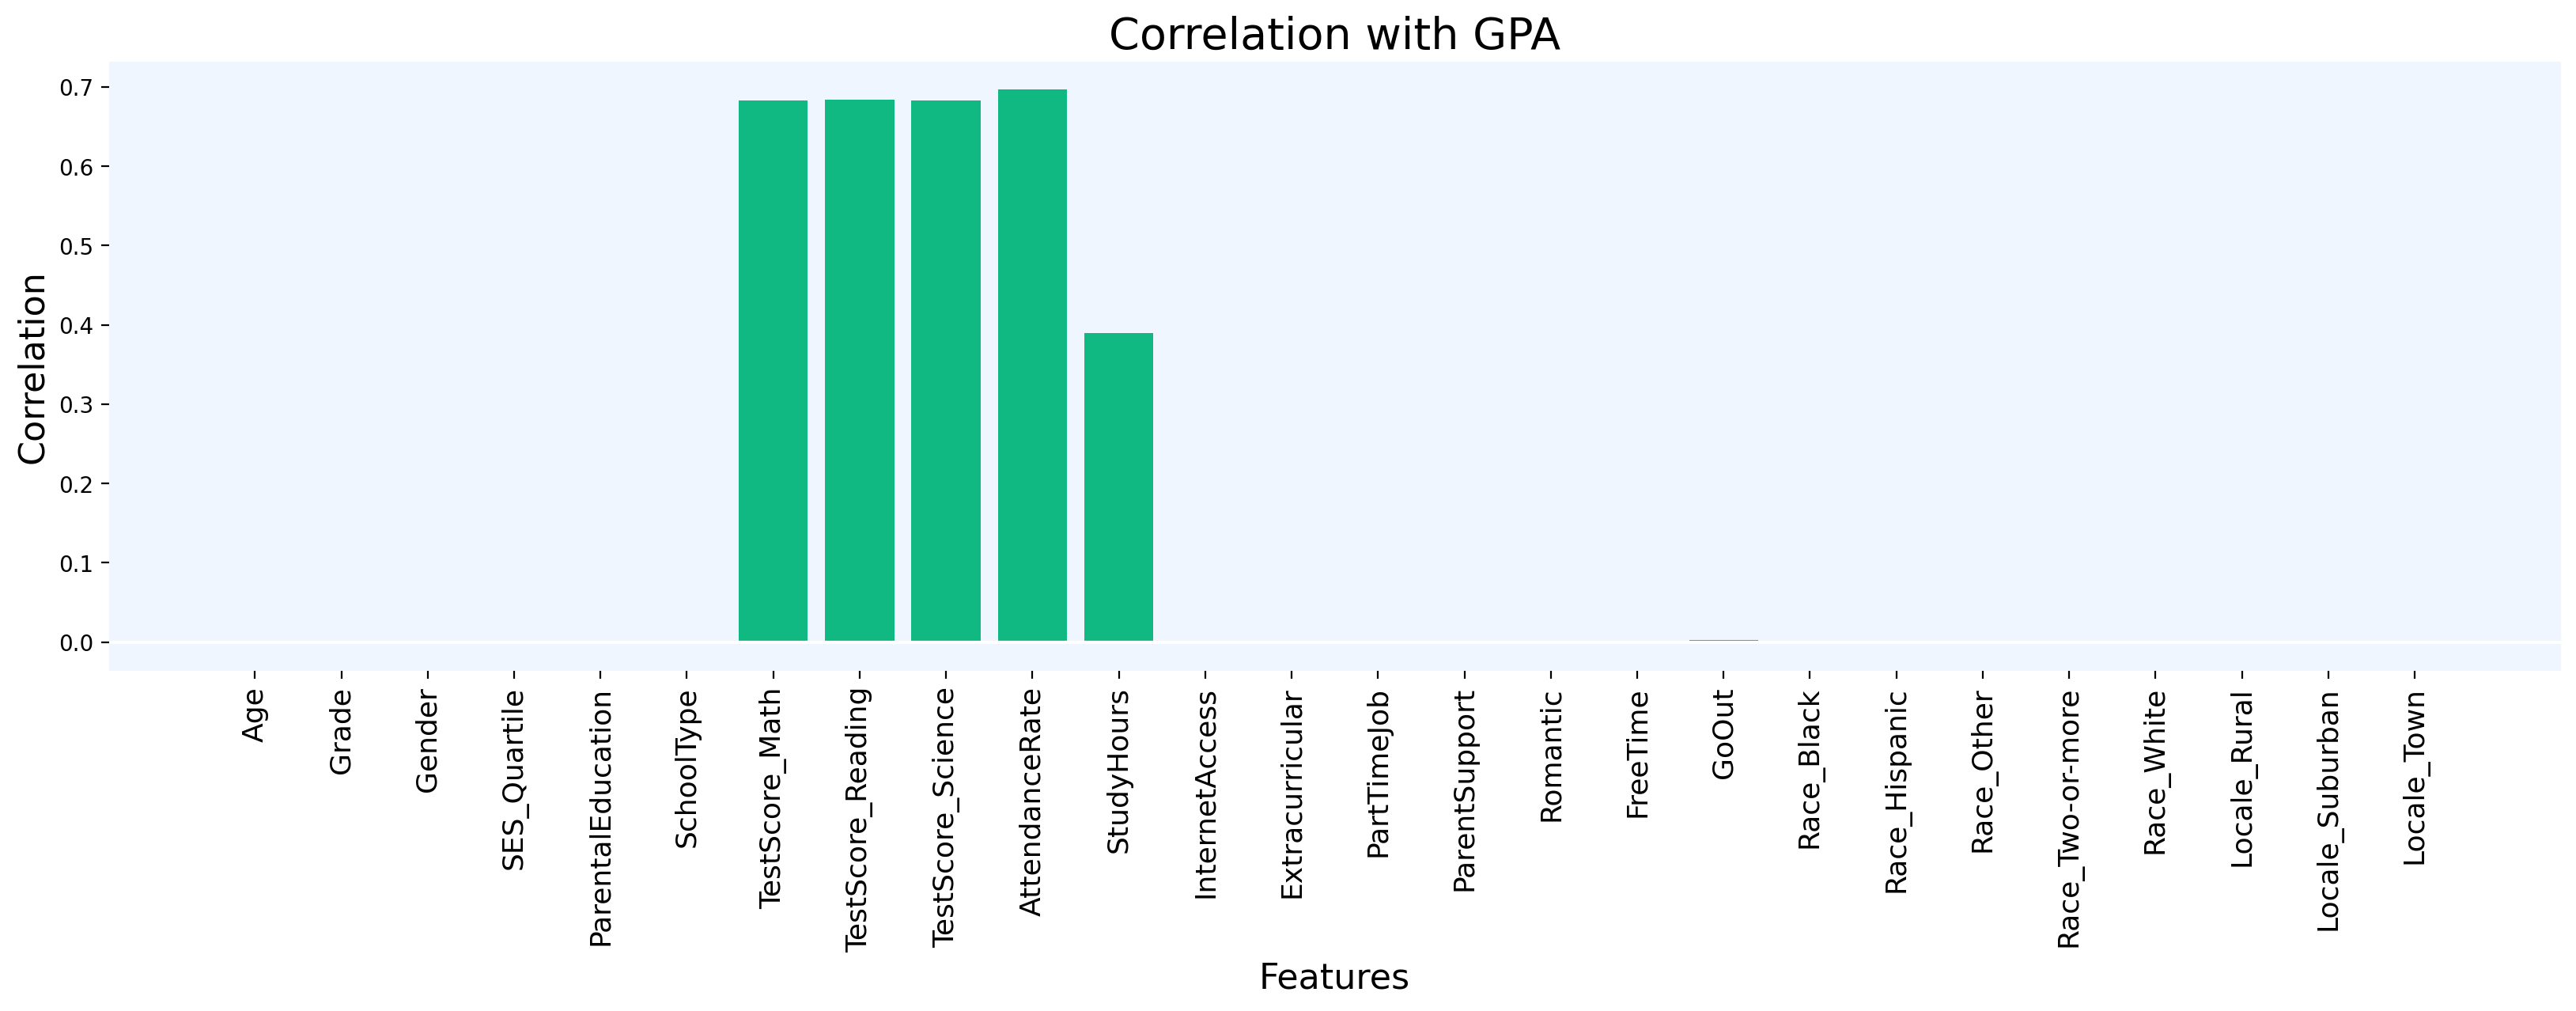

In [24]:
plt.figure(figsize=(20,5), dpi=200)
cor_df = df.corr()['GPA']
cor_df.pop('GPA')
colors = ['#10b981' if corr > 0 else '#059669' for corr in cor_df]
plt.bar(cor_df.index, cor_df, color=colors)
setGraphBG(title='Correlation with GPA', xlabel='Features', ylabel='Correlation', xtick_angle=90)
plt.axhline(y=0, color='white')

# Train Test Split

In [25]:
X = df.drop('GPA', axis=1)
y = df['GPA']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression

In [27]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = pd.Series(model.predict(X_test), index=X_test.index, name='GPA')

# Explainable AI

In [28]:
xpl = SmartExplainer(model=model)

xpl.compile(
    x=X_test,
    y_pred=y_pred
)

INFO: Shap explainer type - shap.explainers.PermutationExplainer()


PermutationExplainer explainer:  38%|███▊      | 75229/200000 [22:03<36:53, 56.36it/s]  


KeyboardInterrupt: 